# Installing and using the bagelR package

## Installing bagelR

The **bagelR** package can be installed via an interactive **R** session using the following code.

In [1]:
if(system.file(package = "bagelR") != "")
    {
      remove.packages("bagelR")
    }
library("remotes")
install_github("grosed/bagel/bagelR",force=TRUE)

Removing package from ‘/home/grosed/DASS/R-packages’
(as ‘lib’ is unspecified)




Running `R CMD build`...



* checking for file ‘/tmp/RtmpYLzaAR/remotes39a0ce3bdc6ba9/grosed-bagel-73be84f/bagelR/DESCRIPTION’ ... OK
* preparing ‘bagelR’:
* checking DESCRIPTION meta-information ... OK
* cleaning src
* installing the package to process help pages
* saving partial Rd database
* cleaning src
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building ‘bagelR_1.0.tar.gz’


Installing package into ‘/home/grosed/DASS/R-packages’
(as ‘lib’ is unspecified)



## Check package version

In [2]:
packageVersion("bagelR")

[1] ‘1.0’

## Using bagelR

### Example 1 - detecting a change in slope

#### load the bagel package

In [3]:
library(bagelR)


Attaching package: ‘bagelR’


The following object is masked from ‘package:stats’:

    time




#### generate some test data

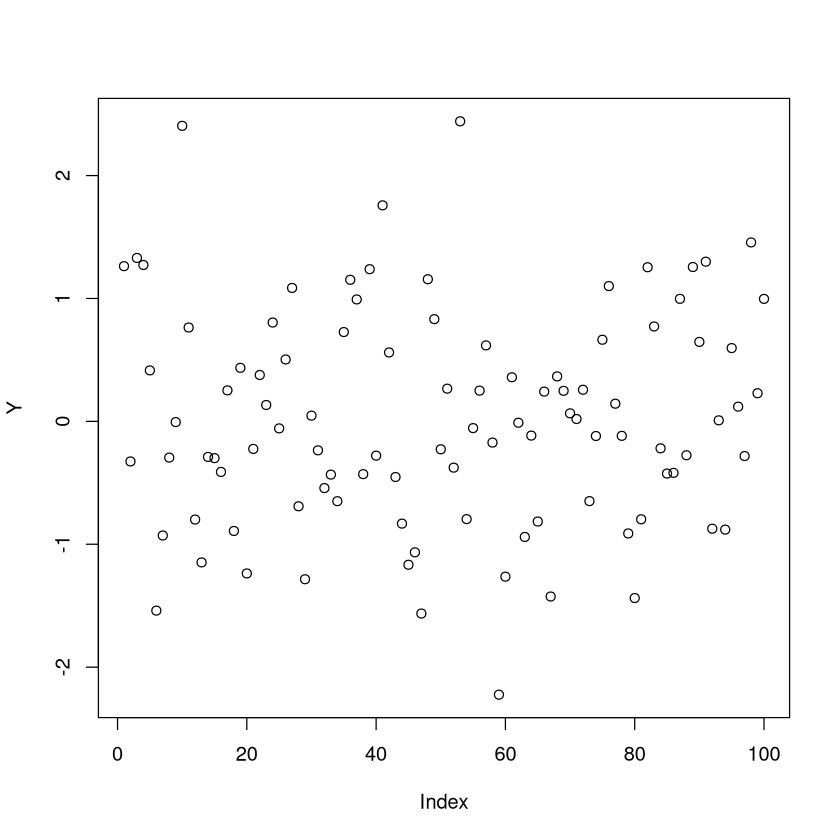

In [4]:
set.seed(0)
Y <- rnorm(100,0,1)
plot(Y)

#### Define the feature vector function

In [9]:
feature_vector <- function(t,tau)
{
  if(tau == 0)
  {
     M <- matrix(c(0),nc=1,nr=2)	  
     M[1,1] <- 1
     M[2,1] <- t
     return(M)
  }
  else
  {
    M <- matrix(c(0),nc=1,nr=4)	  
    M[1,1] <- 1
    M[2,1] <- t
    if(t > tau)
    {
      M[3,1] <- 1
      M[4,1] <- t
    }
  return(M)
  }
}

#### Define the prior function

In [10]:
prior <- function(t)
{
  if(t == 1)
  {
     mu <- matrix(c(0),nc=1,nr=2)
     sigma <- diag(2)
     return(list("mu" = mu,"sigma" = sigma))
  }
  mu <- matrix(c(0),nc=1,nr=4)
  sigma <- diag(4)
  sigma[3,3] <- (t-1)*(t-1)
  sigma[4,3] <- sigma[3,4] <- -(t-1)
  return(list("mu" = mu,"sigma" = sigma))
}

#### Set model parameters 

In [18]:
p <- 1.0;
p0 <- 0.9;
s <- 1.0;
n <- 1000

#### Create a new bagel model

In [19]:
model <- bagel(feature_vector,prior,p0,p,s,n)

#### Set up storage for results

In [20]:
w0s <- c()

#### Analyse the data as if running online

In [21]:
for(y in Y)
{
  # update the model with the most recent data and store the weight at tau = 0  
  w0 <- update(model,y)
  w0s <- c(w0s,w0) # log the result  
}

ERROR: Error in .local(object, ...): object 'x' not found


#### Visualise weight for tau = 0

In [ ]:
plot(w0s)

#### test for changes in mean

In [11]:
result <- bagel_mean(y,decay,probability,mu,tau,delta,sigma,threshold,error,K)

#### location of change

In [12]:
result$stoppingtime

[1] 266

### Example 2 - detecting a change in slope

#### generate test data

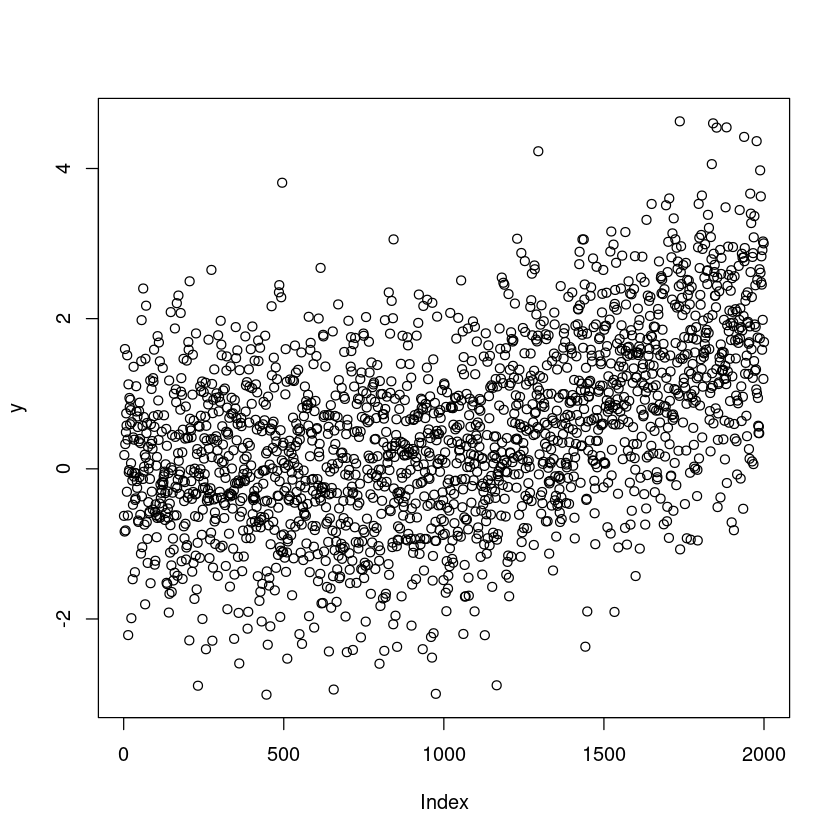

In [13]:
set.seed(1)
y <- generate_piecewise_linear_data(2000,1000,0,0,-2.2,0.002,1,continuous=T)
plot(y)

#### set model parameters

In [20]:
p_dis <- 0.1
p_conti <- 0.1
decay <- 1
mu0 <- c(0,0)
delta_1 <- 0.5^2
delta_2 <- 0.5^2
delta_3 <- 0.5
delta_4 <- 1
sigma2 <- 1
thresh <- 0.89
error <- 'KL'
K <- 50
prior <- 'prior1'

In [21]:
result <- bagel_slope(y, p_dis, p_conti, decay, mu0, delta_1, delta_2, delta_3, delta_4,
                      sigma2, thresh, error, K, prior)

In [19]:
result$stoppingtime

[1] 1283